In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
from spatialdata.models import Image2DModel
import numpy as np
import tifffile
import spatialdata as sd
import pandas as pd
from skimage.measure import regionprops_table
import spatialdata_plot
import spatialdata_io
import matplotlib.pyplot as plt
import seaborn as sns
import zarr
from copy import copy
import matplotlib.colors as mcolors
import dask.array as da
import skimage.measure
import xmltodict
from spatialdata import SpatialData
import spatialdata as sd


In [ ]:
def ismember(a, b):
    bind = {}
    for i, elt in enumerate(b):
        if elt not in bind:
            bind[elt] = i
    result = np.array([bind.get(itm, None) for itm in a])  # None can be replaced by any other "not in b" value
    result = [result, np.array([not x is None for x in result])]
    return result

def grep(pattern, my_list):
    valid_entries = np.array([pattern in x for x in my_list])
    return np.array(my_list)[valid_entries]
    
def grep_exclude(pattern, my_list):
    valid_entries = np.array([pattern in x for x in my_list])
    return np.array(my_list)[np.logical_not(valid_entries)]

def imnormalize(img, quantile_low = 0.1, quantile_high = 0.99):
    img = img - np.quantile(np.ravel(img), quantile_low)
    img = img / np.quantile(np.ravel(img), quantile_high)
    img = np.clip(img, 0, 1)
    return(img)

def im2rgb(IM, color, quantile_high = 0.99, quantile_low = 0.1):
    norm = imnormalize(IM, quantile_low = quantile_low, quantile_high = quantile_high)
    RGB = np.zeros(list(norm.shape) + [3])
    for i in range(len(color)):
        RGB[...,i] = color[i] * norm
    return(RGB)

def imblend(G, R = [], B = []):
    G = im2rgb(G, [0,1,0])
    if len(R) > 0:
        R = im2rgb(R, [1,0,0])
    else:
        R = np.zeros(R.shape)
    if len(B) > 0:
        B = im2rgb(B, [0,0,1])
    else:
        B = np.zeros(B.shape)
    IM = R + G + B
    return(IM)

def imoverlay(IM, mask, color=[1,1,1], px=0):
    from skimage.segmentation import find_boundaries
    if len(IM.shape) == 2:
        overlay_data = im2rgb(IM, [1,1,1])
    else:
        overlay_data = IM.copy()
    boundary = find_boundaries(mask, connectivity=1, mode='inner')
    boundary_mask = np.zeros(overlay_data.shape[:2])
    boundary_mask[boundary > 0] = 1
    if px > 0:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(px,px))
        boundary_mask = cv2.dilate(boundary_mask,kernel,iterations = 1)
    for i in range(len(color)):
        overlay_data[boundary_mask > 0,i] = color[i]
    return(overlay_data)

In [ ]:
SLIDE_ID = "JR-sp-15-011"
rawdatapath = "../rawdata"

possible_files = grep("20251125", grep(SLIDE_ID, os.listdir(rawdatapath)))
selected_file = possible_files[np.array([x.endswith("tiff") for x in possible_files])][0]
ome_tiff_file1 = os.path.join(rawdatapath, selected_file)

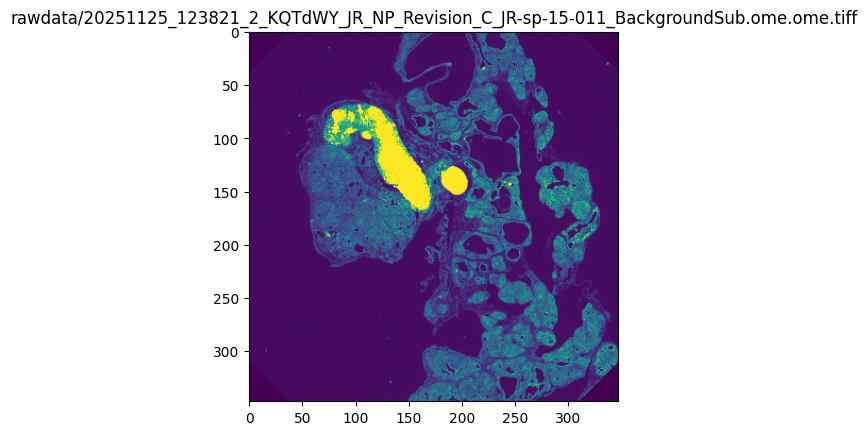

In [ ]:
import tifffile
rawdatapath = "../rawdata"
experiments = np.sort(os.listdir(rawdatapath))
selected_files = [ome_tiff_file1]
for current_image_file in selected_files:
    with tifffile.TiffFile(current_image_file) as tif:
        series_index = 0
        num_levels = len(tif.series[series_index].levels)
        lowest_res_image = tif.series[series_index].levels[num_levels - 1].asarray()
        plt.figure()
        plt.imshow(lowest_res_image[0,:,:], vmax = 1000)
        plt.title(current_image_file)

In [ ]:
# read comet
img_zarr = tifffile.imread(
    ome_tiff_file1,
    aszarr=True,
    level=0,
)
img_da = da.from_zarr(img_zarr)

with tifffile.TiffFile(ome_tiff_file1) as tif:
    # Assuming OME-XML is in the ImageDescription tag of the first page
    # Adjust if your OME-XML is located elsewhere within the TIFF tags
    ome_xml_string = tif.pages[0].tags['ImageDescription'].value
    ome_metadata = xmltodict.parse(ome_xml_string)
channel_names = np.array([x['@Name'] for x in ome_metadata['OME']['Image']['Pixels']['Channel']])
display(channel_names)
channels_simple=['DAPI', 'CC3', 'dpERK', 'p19', 'HMGA2', 'CPA1', 'ANXA10','LGALS4', 'MSN','E-cadherin', 'RFP','GFP', 'VIM']
selected_channels = channels_simple
channel_indexes = ismember(selected_channels, channels_simple)[0]
img_da = img_da[channel_indexes,:,:]

/data1/lowes/reyesj3/miniconda3/envs/spatialdata2/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


array(['DAPI', 'Cleaved caspase 3 (Asp175) 1_50 (NP) - Cy5',
       'dpERK 9101 (NP) - TRITC', 'p19 (NP) - Cy5', 'HMGA2 (NP) - TRITC',
       'Carboxypeptidase A1 (NP) - Cy5', 'AnnexinA10 (NP) - TRITC',
       'Galectin 4 (NP) - Cy5', 'MSN (NP) - TRITC',
       'E-cadherin (NP) - TRITC', 'Anti mKate (RFP) (NP) - Cy5',
       'GFP (NP) - Cy5', 'Vimentin CST (NP) - Cy5'], dtype='<U42')

In [ ]:
scale_factors = [1,2,4,8]
sdImage = sd.models.Image2DModel.parse(img_da, scale_factors=scale_factors, c_coords=selected_channels, dims=["c", "y", "x"])

In [ ]:
sdata = SpatialData({'COMET': sdImage})

In [ ]:
sdata_path = "../sdata"
os.makedirs(sdata_path, exist_ok=True)
path_output = os.path.join(sdata_path, SLIDE_ID)
sdata.write(path_output, overwrite = True)

In [ ]:
sdata = sd.read_zarr(path_output)

In [ ]:
sdata

SpatialData object, with associated Zarr store: /data1/peerd/COMET/sdata/JR-sp-40-19
└── Images
      └── 'JR-sp-40-19': DataTree[cyx] (17, 44643, 44643), (17, 44643, 44643), (17, 22321, 22321), (17, 5580, 5580), (17, 697, 697)
with coordinate systems:
    ▸ 'global', with elements:
        JR-sp-40-19 (Images)